In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
# Path() is better than hardcoded strings — works on Windows and Mac
PROJECT_ROOT = Path("..").resolve()
DATA_PATH    = PROJECT_ROOT / "data" / "metrics_159d.csv"
OUTPUT_PATH  = PROJECT_ROOT / "outputs" / "eda"
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"]     = 120

print(f"Data file exists: {DATA_PATH.exists()}")
print(f"Output dir: {OUTPUT_PATH}")

Data file exists: True
Output dir: C:\Users\akash\OneDrive\Desktop\ecomDigest\ecom-digest\outputs\eda


In [2]:
# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH, parse_dates=["date"])

# Basic shape
print(f"Shape: {df.shape}")
print(f"\nDate range: {df['date'].min().date()}  →  {df['date'].max().date()}")
print(f"Total days: {(df['date'].max() - df['date'].min()).days + 1}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nNull counts:\n{df.isnull().sum()}")

Shape: (19152, 7)

Date range: 2025-09-01  →  2026-02-07
Total days: 160

Dtypes:
date             datetime64[ns]
source                   object
metric                   object
channel                  object
campaign                 object
customer_type            object
value                   float64
dtype: object

Null counts:
date                 0
source               0
metric               0
channel           1920
campaign          2673
customer_type    18192
value                0
dtype: int64


In [3]:
# ── Unique values per categorical column ──────────────────────────────────────
for col in ["source", "metric", "channel", "customer_type"]:
    vals = df[col].fillna("(empty)").unique()
    print(f"\n{col} ({len(vals)} unique):")
    for v in sorted(vals):
        n = df[df[col].fillna("(empty)") == v].shape[0]
        print(f"  {v:30s}  {n:6,} rows")


source (3 unique):
  google_ads                      11,610 rows
  meta_ads                         4,869 rows
  shopify                          2,673 rows

metric (15 unique):
  aov                                731 rows
  attributed_orders                1,831 rows
  attributed_revenue               1,831 rows
  clicks                           1,831 rows
  cpc                              1,831 rows
  cpm                              1,831 rows
  ctr                              1,831 rows
  impressions                      1,831 rows
  new_customer_share                 160 rows
  new_orders                         160 rows
  orders                             731 rows
  returning_orders                   160 rows
  revenue                            731 rows
  roas                             1,831 rows
  spend                            1,831 rows

channel (10 unique):
  (empty)                          1,920 rows
  direct                             126 rows
  email          

In [4]:
# ── Row counts and value stats per source+metric ──────────────────────────────
summary = (
    df.groupby(["source", "metric"])["value"]
    .agg(count="count", min="min", max="max", mean="mean", std="std", median="median")
    .round(2)
    .reset_index()
)
pd.set_option("display.max_rows", 60)
display(summary)

,source,metric,count,min,max,mean,std,median
0,google_ads,attributed_orders,1290,0.00,31.00,2.90,4.00,2.00
1,google_ads,attributed_revenue,1290,0.00,688667.01,29600.83,57086.80,6449.11
2,google_ads,clicks,1290,1.00,93505.00,795.70,3184.21,229.50
3,google_ads,cpc,1290,0.88,665.82,41.90,38.14,35.05
4,google_ads,cpm,1290,19.96,8584.45,1306.85,1661.15,632.92
5,google_ads,ctr,1290,0.00,0.40,0.04,0.05,0.02
6,google_ads,impressions,1290,195.00,1299723.00,39219.86,71591.72,12300.50
7,google_ads,roas,1290,0.00,1182.86,8.35,43.79,0.29
8,google_ads,spend,1290,22.35,129788.20,18907.15,19971.86,11018.15
9,meta_ads,attributed_orders,541,0.00,59.00,5.60,7.62,2.00


In [5]:
# ── Shopify daily totals: revenue ─────────────────────────────────────────────
# Long format → we must filter explicitly. No channel, no campaign, no customer_type
# means it's the "total" row per the data dictionary.

daily = (
    df[
        (df["source"] == "shopify") &
        (df["metric"] == "revenue") &
        (df["channel"].isna() | (df["channel"] == "")) &
        (df["customer_type"].isna() | (df["customer_type"] == ""))
    ]
    .groupby("date")["value"]
    .sum()
    .reset_index()
    .rename(columns={"value": "revenue"})
    .sort_values("date")
)

print(f"Daily revenue rows: {len(daily)}")
print(f"Missing dates: {159 - len(daily)}")
print(f"\nRevenue stats (INR):")
print(daily["revenue"].describe().apply(lambda x: f"₹{x:,.0f}"))

Daily revenue rows: 160
Missing dates: -1

Revenue stats (INR):
count          ₹160
mean     ₹2,436,088
std        ₹883,573
min        ₹115,087
25%      ₹1,802,168
50%      ₹2,263,679
75%      ₹2,941,152
max      ₹5,649,361
Name: revenue, dtype: object


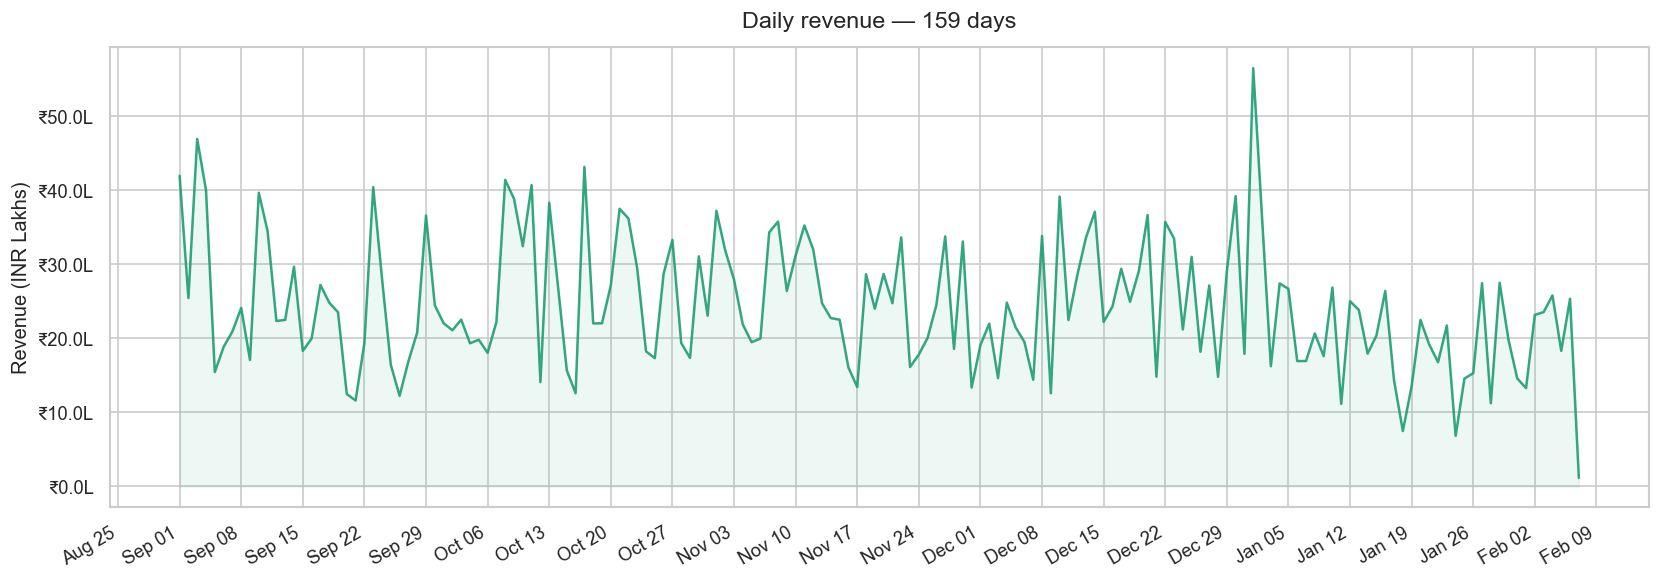

Saved.


In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(daily["date"], daily["revenue"], color="#1D9E75", linewidth=1.5, alpha=0.9)
ax.fill_between(daily["date"], daily["revenue"], alpha=0.08, color="#1D9E75")

# Format axes
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))  # Monday ticks
plt.xticks(rotation=30, ha="right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x/1e5:.1f}L"))

ax.set_title("Daily revenue — 159 days", fontsize=14, pad=12)
ax.set_xlabel("")
ax.set_ylabel("Revenue (INR Lakhs)")

plt.tight_layout()
plt.savefig(OUTPUT_PATH / "01_revenue_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

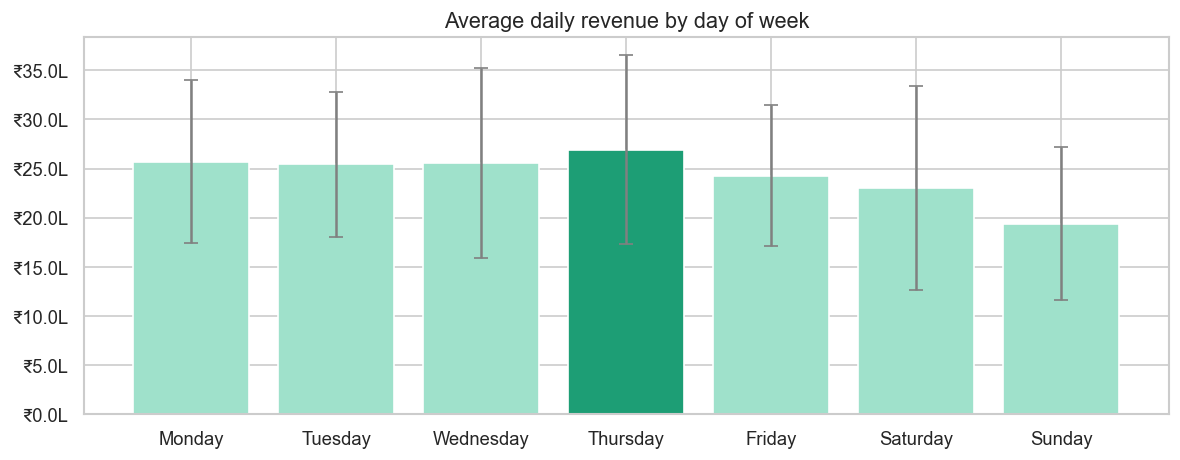

      dow         mean          std
   Monday 2.570272e+06 8.261872e+05
  Tuesday 2.544078e+06 7.362496e+05
Wednesday 2.556550e+06 9.683562e+05
 Thursday 2.693381e+06 9.604889e+05
   Friday 2.426230e+06 7.188196e+05
 Saturday 2.301533e+06 1.039988e+06
   Sunday 1.938954e+06 7.778815e+05


In [7]:
# ── Day-of-week patterns ───────────────────────────────────────────────────────
daily["dow"] = daily["date"].dt.day_name()
daily["dow_n"] = daily["date"].dt.dayofweek  # 0=Monday

dow_avg = (
    daily.groupby(["dow_n", "dow"])["revenue"]
    .agg(mean="mean", median="median", std="std")
    .reset_index()
    .sort_values("dow_n")
)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(dow_avg["dow"], dow_avg["mean"] / 1e5,
              color=["#1D9E75" if v == dow_avg["mean"].max() else "#9FE1CB"
                     for v in dow_avg["mean"]])
ax.errorbar(dow_avg["dow"], dow_avg["mean"] / 1e5,
            yerr=dow_avg["std"] / 1e5, fmt="none", color="gray", capsize=4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x:.1f}L"))
ax.set_title("Average daily revenue by day of week", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "02_dow_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()

print(dow_avg[["dow", "mean", "std"]].to_string(index=False))

Anomaly days (|z| > 2): 4
      date    revenue    roll_mean   z_score
2025-10-08 4139726.54 2.317186e+06  2.374162
2025-12-10 3915419.80 2.279084e+06  2.270135
2026-01-01 5649360.66 2.743894e+06  2.963107
2026-02-07  115086.69 1.815243e+06 -2.499377


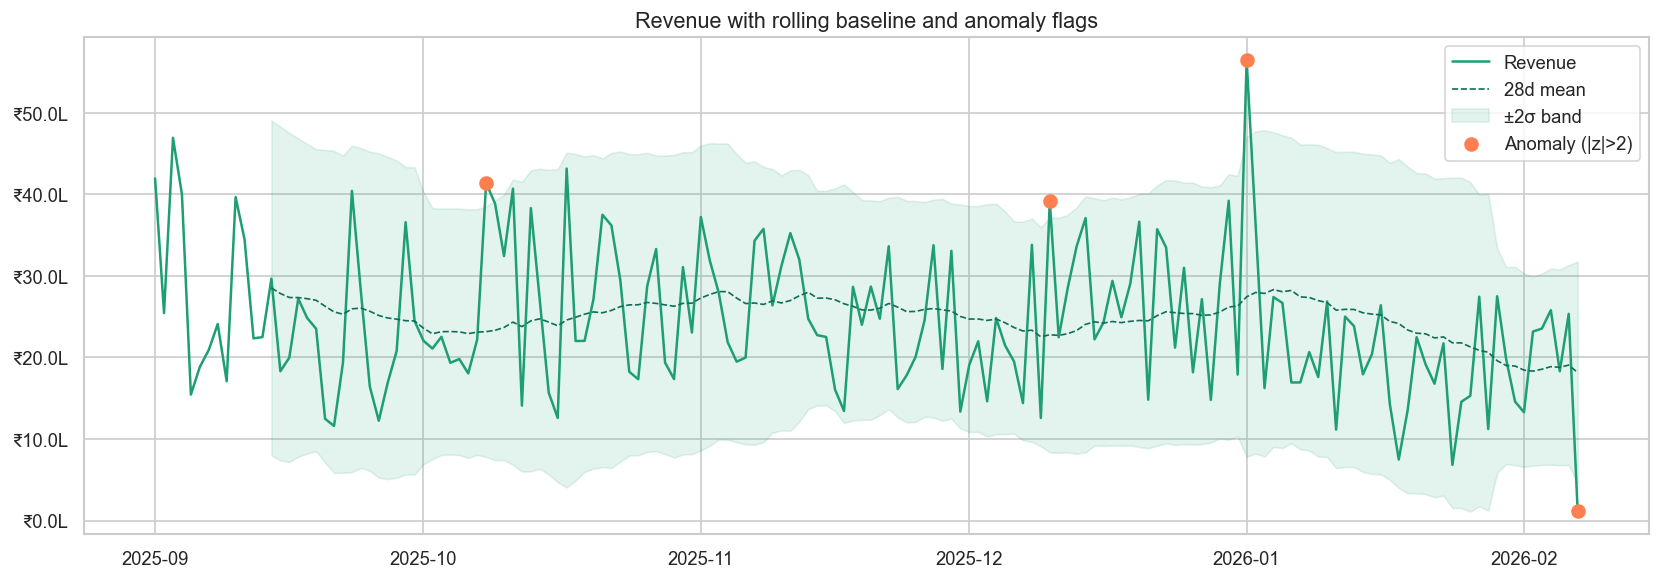

In [8]:
# ── 28-day rolling mean and ±2σ bands ─────────────────────────────────────────
# This is the core statistical primitive your ranker will use in Phase 2

daily = daily.sort_values("date").reset_index(drop=True)
daily["roll_mean"] = daily["revenue"].rolling(28, min_periods=14).mean()
daily["roll_std"]  = daily["revenue"].rolling(28, min_periods=14).std()
daily["upper"]     = daily["roll_mean"] + 2 * daily["roll_std"]
daily["lower"]     = daily["roll_mean"] - 2 * daily["roll_std"]
daily["z_score"]   = (daily["revenue"] - daily["roll_mean"]) / daily["roll_std"]

# Flag anomalies (|z| > 2)
anomalies = daily[daily["z_score"].abs() > 2]
print(f"Anomaly days (|z| > 2): {len(anomalies)}")
print(anomalies[["date", "revenue", "roll_mean", "z_score"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily["date"], daily["revenue"] / 1e5, color="#1D9E75", lw=1.5, label="Revenue")
ax.plot(daily["date"], daily["roll_mean"] / 1e5, color="#0F6E56", lw=1, ls="--", label="28d mean")
ax.fill_between(daily["date"], daily["lower"] / 1e5, daily["upper"] / 1e5,
                alpha=0.12, color="#1D9E75", label="±2σ band")
ax.scatter(anomalies["date"], anomalies["revenue"] / 1e5,
           color="coral", s=60, zorder=5, label="Anomaly (|z|>2)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x:.1f}L"))
ax.legend(); ax.set_title("Revenue with rolling baseline and anomaly flags", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "03_anomaly_bands.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# ── WoW delta ─────────────────────────────────────────────────────────────────
daily["prev_week_revenue"] = daily["revenue"].shift(7)
daily["wow_delta_pct"] = (daily["revenue"] - daily["prev_week_revenue"]) / daily["prev_week_revenue"] * 100

# Last 4 weeks
last_28 = daily.tail(28)[["date", "dow", "revenue", "prev_week_revenue", "wow_delta_pct"]].copy()
last_28["revenue_L"] = last_28["revenue"] / 1e5
last_28["prev_L"]    = last_28["prev_week_revenue"] / 1e5

print("Last 28 days — WoW delta:")
print(last_28[["date", "dow", "revenue_L", "prev_L", "wow_delta_pct"]].round(1).to_string(index=False))

Last 28 days — WoW delta:
      date       dow  revenue_L  prev_L  wow_delta_pct
2026-01-11    Sunday       11.2    27.4          -59.3
2026-01-12    Monday       25.0    26.7           -6.3
2026-01-13   Tuesday       23.8    16.9           40.8
2026-01-14 Wednesday       17.9    16.9            5.9
2026-01-15  Thursday       20.4    20.7           -1.3
2026-01-16    Friday       26.4    17.6           50.0
2026-01-17  Saturday       14.3    26.9          -46.7
2026-01-18    Sunday        7.5    11.2          -32.9
2026-01-19    Monday       13.6    25.0          -45.8
2026-01-20   Tuesday       22.5    23.8           -5.7
2026-01-21 Wednesday       19.2    17.9            6.9
2026-01-22  Thursday       16.8    20.4          -17.7
2026-01-23    Friday       21.7    26.4          -17.7
2026-01-24  Saturday        6.8    14.3          -52.3
2026-01-25    Sunday       14.6     7.5           94.6
2026-01-26    Monday       15.3    13.6           12.9
2026-01-27   Tuesday       27.5    22.5

Correlation matrix:
              revenue  meta_spend  google_spend
revenue         1.000       0.120         0.151
meta_spend      0.120       1.000         0.073
google_spend    0.151       0.073         1.000


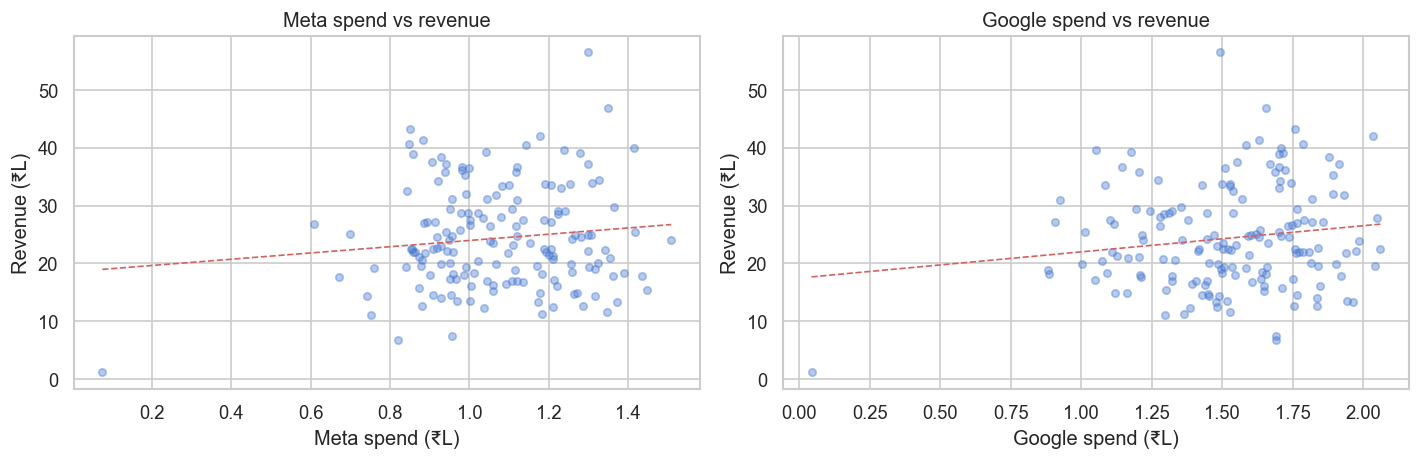

In [10]:
# ── Correlate ad spend with revenue ───────────────────────────────────────────
meta_spend = (
    df[(df["source"] == "meta_ads") & (df["metric"] == "spend")]
    .groupby("date")["value"].sum().rename("meta_spend")
)
google_spend = (
    df[(df["source"] == "google_ads") & (df["metric"] == "spend")]
    .groupby("date")["value"].sum().rename("google_spend")
)

combined = (
    daily.set_index("date")[["revenue"]]
    .join(meta_spend)
    .join(google_spend)
    .dropna()
)

print("Correlation matrix:")
print(combined.corr().round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label in zip(axes, ["meta_spend", "google_spend"], ["Meta", "Google"]):
    ax.scatter(combined[col] / 1e5, combined["revenue"] / 1e5, alpha=0.4, s=20)
    ax.set_xlabel(f"{label} spend (₹L)"); ax.set_ylabel("Revenue (₹L)")
    ax.set_title(f"{label} spend vs revenue")
    m, b = np.polyfit(combined[col], combined["revenue"], 1)
    x_line = np.linspace(combined[col].min(), combined[col].max(), 100)
    ax.plot(x_line / 1e5, (m * x_line + b) / 1e5, "r--", lw=1)
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "04_spend_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# ── Structured summary to paste into design doc ───────────────────────────────
summary_text = f"""
## EDA Key Findings — metrics_159d.csv

**Dataset overview**
- Date range: {daily['date'].min().date()} to {daily['date'].max().date()} ({len(daily)} days)
- Sources: meta_ads, google_ads, shopify
- Total rows: {len(df):,}

**Revenue (INR)**
- Median daily: ₹{daily['revenue'].median():,.0f}
- Min: ₹{daily['revenue'].min():,.0f}  Max: ₹{daily['revenue'].max():,.0f}
- Best day of week (avg): {dow_avg.loc[dow_avg['mean'].idxmax(), 'dow']}
- Worst day of week (avg): {dow_avg.loc[dow_avg['mean'].idxmin(), 'dow']}

**Anomaly detection (28d rolling)**
- Anomaly days (|z|>2): {len(anomalies)}
- Dates: {', '.join(str(d.date()) for d in anomalies['date'])}

**Ad spend correlation with revenue**
- Meta r: {combined[['meta_spend','revenue']].corr().iloc[0,1]:.3f}
- Google r: {combined[['google_spend','revenue']].corr().iloc[0,1]:.3f}

**Attribution caveat**
- ~91% of shopify orders are 'unattributed' at referrer-channel level
- Channel slice is directional only; do not use for causal statements
"""

print(summary_text)

with open(OUTPUT_PATH / "eda_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)
print("Saved to outputs/eda/eda_summary.txt")


## EDA Key Findings — metrics_159d.csv

**Dataset overview**
- Date range: 2025-09-01 to 2026-02-07 (160 days)
- Sources: meta_ads, google_ads, shopify
- Total rows: 19,152

**Revenue (INR)**
- Median daily: ₹2,263,679
- Min: ₹115,087  Max: ₹5,649,361
- Best day of week (avg): Thursday
- Worst day of week (avg): Sunday

**Anomaly detection (28d rolling)**
- Anomaly days (|z|>2): 4
- Dates: 2025-10-08, 2025-12-10, 2026-01-01, 2026-02-07

**Ad spend correlation with revenue**
- Meta r: 0.120
- Google r: 0.151

**Attribution caveat**
- ~91% of shopify orders are 'unattributed' at referrer-channel level
- Channel slice is directional only; do not use for causal statements

Saved to outputs/eda/eda_summary.txt


In [14]:
# ── Verify the shopify total filter is correct ────────────────────────────────
# This catches the triple-counting bug described earlier

# How many rows match our "daily total" filter?
total_rows = df[
    (df["source"] == "shopify") &
    (df["metric"] == "revenue") &
    (df["channel"].isna() | (df["channel"] == "")) &
    (df["customer_type"].isna() | (df["customer_type"] == ""))
]

# How many rows exist for shopify revenue total?
all_shopify_rev = df[
    (df["source"] == "shopify") &
    (df["metric"] == "revenue")
]

print(f"All shopify revenue rows : {len(all_shopify_rev)}")
print(f"After total-only filter  : {len(total_rows)}")
print(f"Unique dates in total    : {total_rows['date'].nunique()}")
print(f"Expected (160 days)      : 160")
print()

# Show the breakdown of channel values for shopify revenue
print("Channel breakdown for shopify revenue rows:")
print(
    df[(df["source"]=="shopify") & (df["metric"]=="revenue")]["channel"]
    .fillna("(null)").value_counts().to_string()
)

All shopify revenue rows : 731
After total-only filter  : 160
Unique dates in total    : 160
Expected (160 days)      : 160

Channel breakdown for shopify revenue rows:
channel
(null)          480
unattributed    160
direct           42
paid             38
other             6
marketplace       2
email             2
organic           1
